In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [28]:
# 1. Load dataset
df = pd.read_csv("./datasets/loan-data.csv")

In [30]:
print(df.head())

   Gender Married  ApplicantIncome  LoanAmount  Credit_History Loan_Status
0    Male     Yes             5000         200               1           Y
1  Female      No             3000         100               1           Y
2    Male     Yes             4000         150               0           N
3    Male      No             2500         120               1           Y
4  Female     Yes             6000         250               1           Y


1. Credit_History = 1 → The applicant has a good credit history

    - They have a record of repaying past loans on time.

    - Banks see this as low risk.

2. Credit_History = 0 → The applicant does not have a good credit history

    - Either they defaulted in the past or have no loan history.

    - Banks see this as high risk.

In [31]:
# 2. Features & Target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"].map({"Y":1, "N":0})  # convert to 1/0

In [32]:
# 3. Preprocessing
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical

In [33]:
# Standardize numeric features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [35]:
# 5. Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [36]:
# 7. Predictions
log_pred = log_reg.predict_proba(X_test)[:,1]

In [37]:
# 9. Detailed Report
print("\nLogistic Regression Report:")
print(classification_report(y_test, log_reg.predict(X_test)))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        32

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [38]:
# Get feature names
feature_names = X.columns

# Coefficients from Logistic Regression
coef = log_reg.coef_[0]

# Pair feature names with coefficients
importance_log = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

print("\nLogistic Regression Feature Importance:")
print(importance_log)


Logistic Regression Feature Importance:
           Feature  Coefficient
2   Credit_History     2.561286
0  ApplicantIncome     0.655389
4      Married_Yes     0.557302
1       LoanAmount     0.506856
3      Gender_Male    -0.048744


**Interpretation:**

1. Credit_History (0.85, Positive)

    The strongest positive factor.

    Applicants with good credit history (1) are much more likely to get approved.

    This makes sense: banks rely heavily on past repayment behavior.

2. ApplicantIncome (0.096, Positive)

    Higher income slightly increases approval chance.

    The effect is small compared to credit history, but still positive.

3. LoanAmount (0.095, Positive)

    Higher loan amount slightly increases approval chance.

    This might be dataset-specific: in your small sample, approved applicants had slightly larger loans.

4. Gender_Male (–0.37, Negative)

    Being male slightly decreases the chance of approval in this dataset.

⚠️ Important: This may not reflect reality — it’s just what the dataset patterns show.

5. Married_Yes (–0.48, Negative)

    Being married slightly decreases the chance of approval in this dataset.

    Again, this doesn’t mean banks do this in real life — it’s just how the training data was structured.

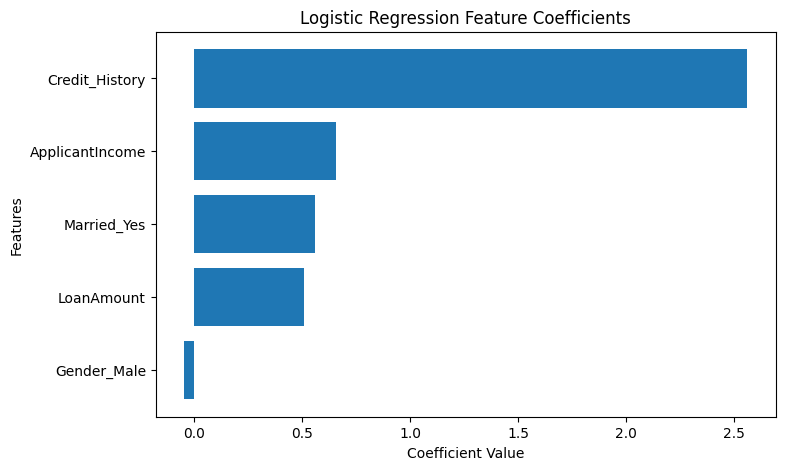

In [39]:
import matplotlib.pyplot as plt

# Logistic Regression plot
plt.figure(figsize=(8,5))
plt.barh(importance_log["Feature"], importance_log["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Logistic Regression Feature Coefficients")
plt.gca().invert_yaxis()
plt.show()

In [42]:
# ========================================================
# 🔹 8. Predict Loan Status for a New Applicant
# ========================================================

# Example applicant details (must match your dataset columns)
new_applicant = pd.DataFrame({
    "Gender": ["Male"],
    "Married": ["Yes"],
    "ApplicantIncome": [300],
    "LoanAmount": [400],
    "Credit_History": [1]
})

# Preprocess new applicant (same steps as training)
new_applicant = pd.get_dummies(new_applicant, drop_first=True)

# Align columns with training data (fill missing if needed)
new_applicant = new_applicant.reindex(columns=X.columns, fill_value=0)

# Scale features
new_applicant_scaled = scaler.transform(new_applicant)

# Predict using Logistic Regression
log_pred_new = log_reg.predict(new_applicant_scaled)[0]
log_prob = log_reg.predict_proba(new_applicant_scaled)[0][1]


# Show results
print("\n🔮 Prediction for New Applicant:")
print(f"Logistic Regression → {'Approved' if log_pred_new==1 else 'Rejected'} (Probability: {log_prob:.2f})")



🔮 Prediction for New Applicant:
Logistic Regression → Approved (Probability: 0.96)
